# Makemore 3 : RNN and How the gradient behaves and Batch Normalization

#### Imports

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

#### Read the dataset

In [2]:
words = open("names.txt", "r").read().splitlines()
print(f'Total Names: {len(words)}')
print(f'First 8 names: {words[:8]}')

Total Names: 32033
First 8 names: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


#### Build the vocabulary of the characters and the mappings to and from integers

In [3]:
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi["."]=0
itos={i:s for s, i in stoi.items()}
vocab_size = len(itos)
print(f'Indexes to string dict: {itos}')
print(f'Len of Indexes to string dictionary (i.e Vocabulary size): {vocab_size}')

Indexes to string dict: {1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
Len of Indexes to string dictionary (i.e Vocabulary size): 27


#### Build the dataset

In [4]:
block_size = 3
def build_dataset(words):
    X, Y = [], []
    for word in words:
        context = [0]*block_size
        for char in word + ".":
            ix = stoi[char]
            X.append(context)
            Y.append(ix)
            context = context[1:]+[ix]
    X= torch.tensor(X)
    Y= torch.tensor(Y)
    print(f'X-Shape:{X.shape}, Y-shape:{Y.shape}')
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1=int(0.8*len(words))
n2=int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) #80%
Xdev, Ydev = build_dataset(words[n1:n2]) #10%
Xte, Yte = build_dataset(words[n2:]) #10%


X-Shape:torch.Size([182625, 3]), Y-shape:torch.Size([182625])
X-Shape:torch.Size([22655, 3]), Y-shape:torch.Size([22655])
X-Shape:torch.Size([22866, 3]), Y-shape:torch.Size([22866])


#### MLP Initiation Now

In [40]:
n_embd = 10 # the dimensionality of the character embedding vector
n_hidden = 200 # The number of neurons in the hioden layer of MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0.2
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(f'Total Number or parameters: {sum(i.nelement() for i in parameters)}')
for p in parameters:
    p.requires_grad=True

Total Number or parameters: 11897


#### Now optimize

In [41]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # Mini batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    emb = C[Xb] # Embed the characters into the vector
    embcat = emb.view(emb.shape[0], -1) # Concatenate the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(hpreact) # Hidden layer
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update
    lr = 0.1 if i<100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr*p.grad

    # Track Stats
    if i%10000==0:
        print(f'{i:7d}/{max_steps:7d}:{loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000:3.3135
  10000/ 200000:2.1648
  20000/ 200000:2.3061
  30000/ 200000:2.4541
  40000/ 200000:1.9787
  50000/ 200000:2.2930
  60000/ 200000:2.4232
  70000/ 200000:2.0680
  80000/ 200000:2.3095
  90000/ 200000:2.1207
 100000/ 200000:1.8269
 110000/ 200000:2.2045
 120000/ 200000:1.9797
 130000/ 200000:2.3946
 140000/ 200000:2.1000
 150000/ 200000:2.1948
 160000/ 200000:1.8619
 170000/ 200000:1.7809
 180000/ 200000:1.9673
 190000/ 200000:1.8295


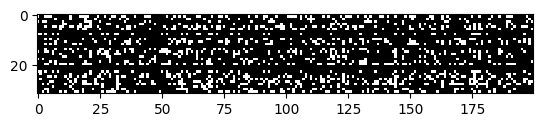

In [42]:
plt.Figure(figsize=(20, 10))
plt.imshow(h.abs()>0.99, cmap="gray", interpolation="nearest")

#### Evaluate Loss for the training

In [ ]:
# 4 dimensional example
# logits = torch.tensor([-0.0249,  0.3523, -0.1267,  0.0541,  0.1662, -0.1171, -0.0140,  0.0124,
#          0.0921,  0.1135,  0.1362, -0.0925,  0.0444, -0.2459, -0.0971,  0.0125,
#         -0.0957, -0.1376, -0.2329, -0.0137,  0.2452,  0.1616,  0.1665, -0.1094,
#         -0.2154,  0.0725,  0.1141])
# probs = F.softmax(logits, dim=0)
# loss = -probs[2].log()
# probs, loss, probs[0]

(tensor([0.0354, 0.0517, 0.0320, 0.0384, 0.0429, 0.0323, 0.0358, 0.0368, 0.0398,
         0.0407, 0.0416, 0.0331, 0.0380, 0.0284, 0.0330, 0.0368, 0.0330, 0.0317,
         0.0288, 0.0358, 0.0464, 0.0427, 0.0429, 0.0326, 0.0293, 0.0391, 0.0407]),
 tensor(3.4415),
 tensor(0.0354))

In [30]:
h

tensor([[ 0.2459, -0.9399,  0.4329,  ..., -0.9999,  1.0000,  0.9999],
        [-0.8430, -1.0000, -1.0000,  ..., -0.8118,  0.9975, -0.6998],
        [-1.0000,  0.9992, -1.0000,  ..., -0.7131, -0.9879,  0.7264],
        ...,
        [-0.9998, -0.9999, -0.9995,  ..., -0.5876, -0.7118, -0.6373],
        [ 0.9867,  0.5539,  1.0000,  ..., -0.9814, -1.0000,  0.9946],
        [-1.0000, -0.9997, -1.0000,  ..., -0.8945, -0.9140,  0.8530]],
       grad_fn=<TanhBackward0>)

(array([607., 150., 115.,  87.,  60.,  56.,  54.,  48.,  39.,  44.,  28.,
         34.,  29.,  28.,  33.,  30.,  22.,  31.,  26.,  24.,  36.,  21.,
         26.,  19.,  12.,  19.,  19.,  22.,  16.,  25.,  18.,  26.,  17.,
         18.,  26.,  14.,  10.,  25.,  18.,  17.,  18.,  20.,  17.,  14.,
         15.,  15.,  19.,  25.,  24.,  18.,  12.,  15.,  13.,  21.,  13.,
         21.,  18.,  19.,  22.,  17.,  13.,  12.,  15.,  25.,  12.,  13.,
          9.,  15.,  13.,  15.,  33.,  16.,  19.,  11.,   6.,  13.,  38.,
         15.,  19.,  33.,  15.,  13.,  22.,  40.,  34.,  15.,  23.,  19.,
         23.,  29.,  30.,  25.,  25.,  23.,  31.,   8.,  10.,  23.,  21.,
         38.,  29.,  30.,  35.,  30.,  31.,  20.,  43.,  39.,  39.,  30.,
          5.,  27.,  14.,  49.,  18.,  20.,  23.,  36.,  27.,  34.,  16.,
         13.,  24.,  18.,  17.,  34.,  23.,  12.,  10.,  15.,  19.,  16.,
         24.,  18.,  17.,  14.,   5.,   6.,  20.,  13.,  18.,  18.,  14.,
         23.,   9.,  21.,  10.,  15., 

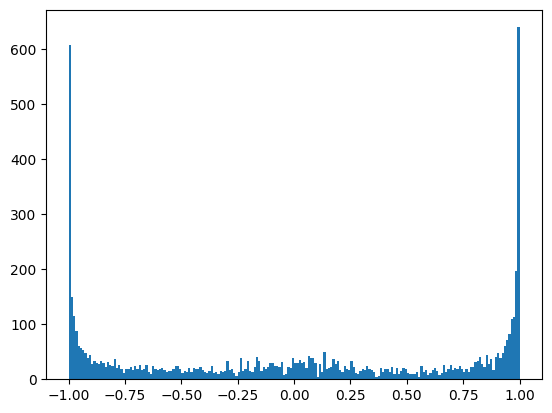

In [43]:
plt.hist(h.view(-1).tolist(), 200)

(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   1.,   0.,   1.,   1.,   0.,   1.,   2.,   0.,   0.,   2.,
          0.,   1.,   1.,   0.,   2.,   1.,   2.,   2.,   1.,   1.,   3.,
          5.,   1.,   2.,   2.,   0.,   4.,   3.,   4.,   2.,   6.,   6.,
          6.,   4.,   2.,   4.,  11.,   4.,   5.,  11.,   4.,  14.,   7.,
         13.,  13.,   7.,   8.,  13.,  10.,  17.,  14.,  19.,  18.,  19.,
         24.,  25.,  26.,  33.,  30.,  31.,  41.,  42.,  39.,  36.,  35.,
         43.,  40.,  42.,  54.,  54.,  55.,  59.,  46.,  67.,  53.,  65.,
         62.,  66.,  78.,  73.,  94.,  78.,  88., 107.,  95., 114., 122.,
        132., 130., 157., 215., 209., 277., 258., 202., 167., 110., 123.,
         76.,  91.,  83.,  93.,  84.,  67., 110.,  74.,  82.,  54.,  66.,
         70.,  76.,  63.,  72.,  61.,  69.,  48.,  52.,  54.,  52.,  55.,
         57.,  44.,  49.,  38.,  25.,  38.,  26.,  26.,  20.,  32.,  16.,
         19.,  25.,  10.,  19.,  16., 

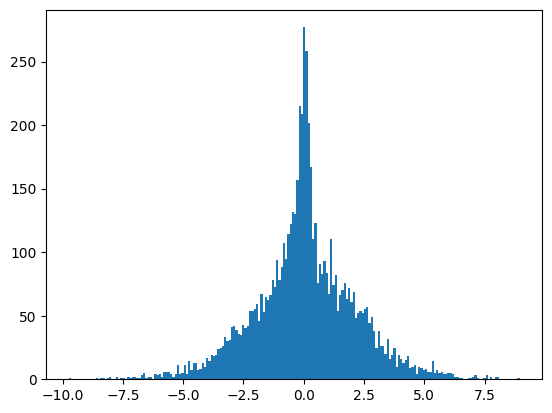

In [44]:
plt.hist(hpreact.view(-1).tolist(), 200)

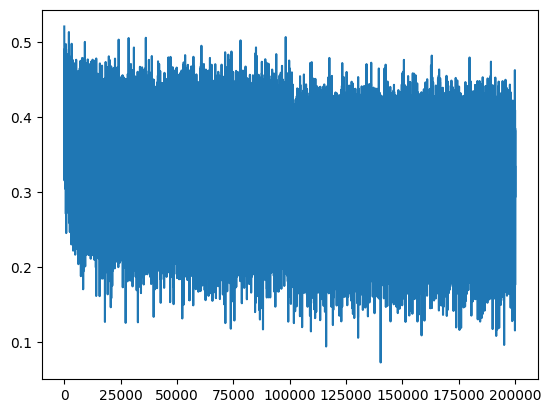

In [45]:
plt.plot(lossi)

#### Now Evaluate

In [29]:
@torch.no_grad() # this decorator disables gradient tracking and saves space
def split_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "val":(Xdev, Ydev), 
        "test":(Xte, Yte)
    }[split]
    emb = C[x] # N, block_size, n_embd
    embcat  = emb.view(emb.shape[0], -1) # Concat into (N, block_size * n_embd)
    h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss("train")
split_loss("val")


train 2.0698275566101074
val 2.1308963298797607


#### Now Sample the model

In [8]:
g = torch.Generator().manual_seed(2147483647 + 10)
for _ in range(20):
    out = []
    context = [0]* block_size

    while True:
        # Forward pass the neural net
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        h = torch.tanh(emb.view(1, -1)@W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)

        # Sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()

        # Shift the sample window and track the samples
        context = context[1:]+[ix]
        out.append(ix)

        # if we sample special token ".", then break
        if ix ==0:
            break

    print("".join(itos[i] for i in out))

carlah.
amelle.
khi.
mili.
taty.
skanden.
jazonen.
den.
art.
kaqui.
ner.
kentzeriav.
kaleigh.
ham.
jore.
quinn.
salin.
alianni.
wazelo.
dearisi.
